# 학습된 수면 모델 성능 확인 (독립 실행)

학습이 중간에 멈췄어도 그 시점까지의 **최고 성능 가중치(`best.pt`)** 는 매 epoch 저장되므로 그대로 평가할 수 있습니다.
이 노트북은 학습 노트북과 독립적으로 동작합니다.

측정 항목
1. 어떤 가중치가 있는지 자동 탐색 + 학습이 어디까지 갔는지 확인
2. 인스턴스 mAP (Box / Mask)
3. **픽셀 IoU / Dice** — 이 과제의 실질 지표
4. conf 임계값 스윕
5. 최악 사례 시각화

## 1. 가중치 자동 탐색

In [1]:
import os, sys, json, csv, shutil
from pathlib import Path

import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ── 수정 지점 ───────────────────────────────────────────────
SEARCH_ROOT = Path(r"C:\Project\PythonProject\PyTorch001")
DATA_YAML   = Path(r"C:\Project\PythonProject\PyTorch001\datasets\water_seg\data.yaml")
DST_ROOT    = Path(r"C:\Project\PythonProject\PyTorch001\datasets\water_seg")
IMGSZ       = 640
# ───────────────────────────────────────────────────────────

DEV = 0 if torch.cuda.is_available() else "cpu"

found = sorted(SEARCH_ROOT.rglob("weights/best.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
if not found:
    raise FileNotFoundError("best.pt 를 찾지 못했습니다. 학습 폴더 경로를 확인하세요.")

print("발견된 가중치 (최신순)")
for i, p in enumerate(found):
    run = p.parent.parent
    csvf = run / "results.csv"
    n_ep = 0
    if csvf.exists():
        with open(csvf, encoding="utf-8") as f:
            n_ep = sum(1 for _ in f) - 1
    size = p.stat().st_size / 1e6
    print(f"  [{i}] {run.name:24s} | {n_ep:4d} epoch | {size:5.1f}MB | {run}")

PICK = 0   # 평가할 가중치 번호
BEST_PT = found[PICK]
SAVE_DIR = BEST_PT.parent.parent
print("\n선택:", BEST_PT)

발견된 가중치 (최신순)
  [0] water_seg_v3_m           |  214 epoch |  54.5MB | C:\Project\PythonProject\PyTorch001\runs_water_v3\water_seg_v3_m
  [1] water_seg_v1             |  100 epoch |   6.5MB | C:\Project\PythonProject\PyTorch001\runs_water\water_seg_v1
  [2] vehicle_detector_v3_y26  |   31 epoch |   5.4MB | C:\Project\PythonProject\PyTorch001\final_project\runs\detect\flood_stage1\vehicle_detector_v3_y26
  [3] vehicle_detector         |    5 epoch |  22.5MB | C:\Project\PythonProject\PyTorch001\final_project\runs\detect\flood_stage1\vehicle_detector

선택: C:\Project\PythonProject\PyTorch001\runs_water_v3\water_seg_v3_m\weights\best.pt


## 2. 중단 시점 확인

`best.pt`는 **fitness가 가장 높았던 epoch**의 가중치입니다.
학습이 강제 종료됐더라도 그 시점까지의 최선이 남아 있으므로 평가에 문제가 없습니다.

완료 epoch: 214
최고 epoch: 174  (mask mAP50-95 0.5144 / mAP50 0.7683)
마지막 epoch 대비: 수렴 후 정체


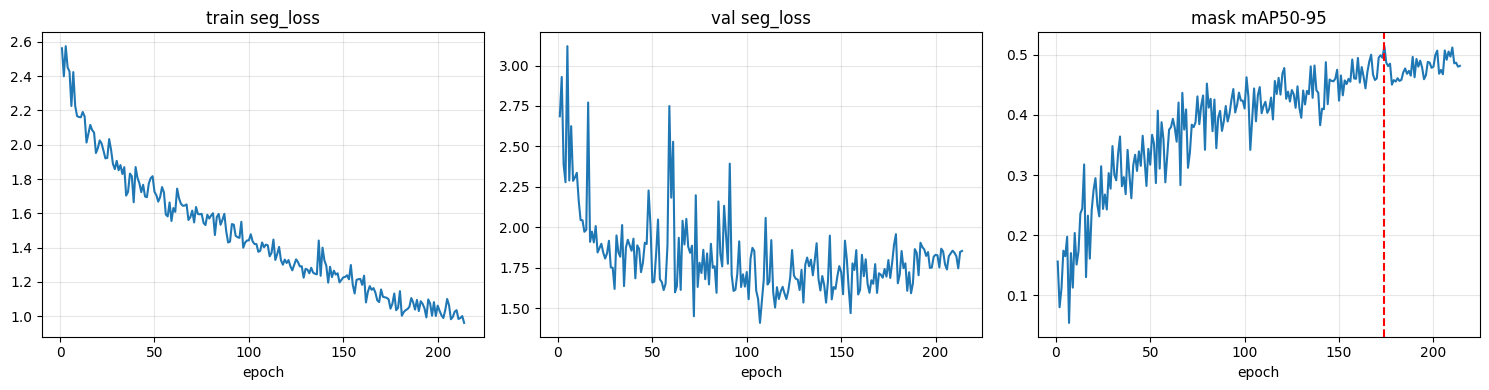

In [2]:
res_csv = SAVE_DIR / "results.csv"
if res_csv.exists():
    with open(res_csv, encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    print(f"완료 epoch: {len(rows)}")

    def col(sub):
        k = next((k for k in rows[0] if sub in k), None)
        return ([float(r[k]) for r in rows], k) if k else (None, None)

    seg95, _ = col("mAP50-95(M)")
    seg50, _ = col("mAP50(M)")
    if seg95:
        be = int(np.argmax(seg95)) + 1
        print(f"최고 epoch: {be}  (mask mAP50-95 {max(seg95):.4f} / mAP50 {seg50[be-1]:.4f})")
        print(f"마지막 epoch 대비: {'개선 여지 있음' if be >= len(rows) - 5 else '수렴 후 정체'}")

        fig, ax = plt.subplots(1, 3, figsize=(15, 4))
        for a, (sub, t) in zip(ax, [("train/seg_loss", "train seg_loss"),
                                    ("val/seg_loss", "val seg_loss"),
                                    ("mAP50-95(M)", "mask mAP50-95")]):
            v, _ = col(sub)
            if v:
                a.plot(range(1, len(v) + 1), v)
                a.set_title(t); a.set_xlabel("epoch"); a.grid(alpha=0.3)
        ax[2].axvline(be, color="r", ls="--")
        plt.tight_layout(); plt.show()
else:
    print("results.csv 없음 — 지표 곡선은 건너뜁니다")

## 3. 인스턴스 mAP

In [3]:
model = YOLO(str(BEST_PT))
print("클래스:", model.names)

def run_val(split):
    try:
        m = model.val(data=str(DATA_YAML), split=split, imgsz=IMGSZ, device=DEV,
                      project=str(SAVE_DIR), name=f"eval_{split}", exist_ok=True, verbose=False)
        print(f"[{split.upper():5s}] Box  mAP50 {m.box.map50:.4f} | mAP50-95 {m.box.map:.4f}")
        print(f"[{split.upper():5s}] Mask mAP50 {m.seg.map50:.4f} | mAP50-95 {m.seg.map:.4f} "
              f"| P {m.seg.mp:.4f} | R {m.seg.mr:.4f}")
        return m
    except Exception as e:
        print(f"[{split}] 실패: {e}")
        return None

m_val  = run_val("val")
m_test = run_val("test")

RuntimeError: PytorchStreamReader failed reading zip archive: failed finding central directory. This is an internal miniz error. If you are seeing this error, there is a high likelihood that your checkpoint file is corrupted. This can happen if the checkpoint was not saved properly, was transferred incorrectly, or the file was modified after saving.

## 4. 픽셀 단위 IoU / Dice

mAP는 인스턴스 지표라 물 한 덩어리를 여러 조각으로 잡으면 점수가 깎입니다.
침수 판정은 마스크를 전부 합쳐 쓰므로 **픽셀 IoU가 실제 성능에 훨씬 가깝습니다.**

In [ ]:
def load_gt_mask(label_path, h, w):
    m = np.zeros((h, w), np.uint8)
    if not label_path.exists():
        return m
    for line in label_path.read_text(encoding="utf-8").splitlines():
        v = line.split()
        if len(v) < 7:
            continue
        pts = np.array(list(map(float, v[1:])), np.float32).reshape(-1, 2)
        pts[:, 0] *= w; pts[:, 1] *= h
        cv2.fillPoly(m, [pts.astype(np.int32)], 1)
    return m


def predict_mask(bgr, conf=0.25):
    h, w = bgr.shape[:2]
    r = model.predict(source=bgr, conf=conf, imgsz=IMGSZ, device=DEV, verbose=False)[0]
    pr = np.zeros((h, w), np.uint8)
    if r.masks is not None:
        for m in r.masks.data.cpu().numpy():
            mm = cv2.resize(m.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
            pr |= (mm > 0.5).astype(np.uint8)
    return pr


def pixel_eval(split="test", conf=0.25, verbose=True, keep_per_image=False):
    img_dir, lbl_dir = DST_ROOT / "images" / split, DST_ROOT / "labels" / split
    files = sorted(img_dir.glob("*.jpg"))
    inter_t = union_t = gt_t = pr_t = 0
    per_img = []

    for f in files:
        bgr = cv2.imread(str(f))
        if bgr is None:
            continue
        h, w = bgr.shape[:2]
        gt = load_gt_mask(lbl_dir / (f.stem + ".txt"), h, w)
        pr = predict_mask(bgr, conf)
        i_ = int(np.logical_and(gt, pr).sum()); u_ = int(np.logical_or(gt, pr).sum())
        inter_t += i_; union_t += u_; gt_t += int(gt.sum()); pr_t += int(pr.sum())
        if keep_per_image and u_ > 0:
            per_img.append((f.name, i_ / u_))

    out = {"iou": inter_t / max(union_t, 1),
           "precision": inter_t / max(pr_t, 1),
           "recall": inter_t / max(gt_t, 1),
           "n": len(files), "per_image": per_img}
    out["dice"] = 2 * out["precision"] * out["recall"] / max(out["precision"] + out["recall"], 1e-9)
    if verbose:
        print(f"[{split}] n={out['n']} conf={conf}")
        print(f"  픽셀 IoU  {out['iou']:.4f} | Dice {out['dice']:.4f}")
        print(f"  픽셀 P    {out['precision']:.4f} | R {out['recall']:.4f}")
    return out

px_val  = pixel_eval("valid")
px_test = pixel_eval("test", keep_per_image=True)

## 5. conf 임계값 스윕 (valid에서 결정)

In [ ]:
sweep = {}
for c in [0.10, 0.15, 0.20, 0.25, 0.35, 0.50]:
    s = pixel_eval("valid", conf=c, verbose=False)
    sweep[c] = s
    print(f"conf={c:<5} IoU {s['iou']:.4f} | P {s['precision']:.4f} | R {s['recall']:.4f}")

best_conf = max(sweep, key=lambda k: sweep[k]["iou"])
print(f"\n최적 conf = {best_conf}  (valid IoU {sweep[best_conf]['iou']:.4f})")
px_test_opt = pixel_eval("test", conf=best_conf)

cs = sorted(sweep)
plt.figure(figsize=(7, 4))
plt.plot(cs, [sweep[c]["iou"] for c in cs], "o-", label="IoU")
plt.plot(cs, [sweep[c]["precision"] for c in cs], "s--", label="pixel P")
plt.plot(cs, [sweep[c]["recall"] for c in cs], "^--", label="pixel R")
plt.axvline(best_conf, color="r", ls=":", alpha=0.6)
plt.xlabel("conf"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 6. 최악 사례 확인 — 어디서 틀리는지가 다음 개선 방향

In [ ]:
worst = sorted(px_test["per_image"], key=lambda x: x[1])[:4]
print("IoU 하위 4장:", [(n, round(v, 3)) for n, v in worst])

if worst:
    fig, axes = plt.subplots(len(worst), 2, figsize=(11, 4.2 * len(worst)))
    axes = np.atleast_2d(axes)
    for r, (name, iou) in enumerate(worst):
        f = DST_ROOT / "images" / "test" / name
        bgr = cv2.imread(str(f)); h, w = bgr.shape[:2]
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        gt = load_gt_mask(DST_ROOT / "labels" / "test" / (f.stem + ".txt"), h, w)
        pr = predict_mask(bgr, best_conf)

        a = rgb.copy(); a[gt == 1] = (0.45 * np.array([0, 255, 0]) + 0.55 * a[gt == 1]).astype(np.uint8)
        b = rgb.copy(); b[pr == 1] = (0.45 * np.array([255, 0, 0]) + 0.55 * b[pr == 1]).astype(np.uint8)
        axes[r, 0].imshow(a); axes[r, 0].set_title(f"GT — {name[:26]}", fontsize=9); axes[r, 0].axis("off")
        axes[r, 1].imshow(b); axes[r, 1].set_title(f"PRED  IoU={iou:.3f}", fontsize=9); axes[r, 1].axis("off")
    plt.tight_layout(); plt.show()

## 7. 요약 + 설정 저장

In [ ]:
print("=" * 52)
print("가중치 :", BEST_PT)
print("-" * 52)
if m_test is not None:
    print(f"TEST  인스턴스 mask mAP50 {m_test.seg.map50:.4f} | mAP50-95 {m_test.seg.map:.4f}")
print(f"TEST  픽셀 IoU {px_test_opt['iou']:.4f} | Dice {px_test_opt['dice']:.4f} "
      f"(conf {best_conf})")
print(f"VALID 픽셀 IoU {sweep[best_conf]['iou']:.4f}")
print("=" * 52)

gap = sweep[best_conf]["iou"] - px_test_opt["iou"]
if gap > 0.08:
    print("→ valid/test 격차가 큽니다. 과적합 또는 test 표본(54장) 편차를 의심하세요.")
if px_test_opt["recall"] < px_test_opt["precision"] - 0.05:
    print("→ 미탐 편향. conf를 더 낮추거나 학습 데이터를 늘리세요.")
elif px_test_opt["precision"] < px_test_opt["recall"] - 0.05:
    print("→ 오탐 편향. 물 없는 배경 이미지를 추가하세요.")

meta = {"weights": str(BEST_PT), "imgsz": IMGSZ, "best_conf": float(best_conf),
        "test_pixel_iou": round(px_test_opt["iou"], 4),
        "test_pixel_recall": round(px_test_opt["recall"], 4)}
out = SAVE_DIR / "eval_meta.json"
out.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
print("\n저장:", out)